In [14]:
%matplotlib inline
import joblib
import shap
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sns
import numpy as np
import json
import os

In [15]:
experiment_path = "2026-08-11-12_11_36_AM_xgboost"

In [16]:
ss = pd.read_csv("../../data/raw/sample_submission.csv")
target_column = ss.columns[-1]
target_column

'addicted_label'

In [17]:
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE'):
    data_path = "/kaggle/input/datasets/abhinavneelam/smartphone-addiction/data"
    output_path = "/kaggle/working/"
else:
    data_path = "../../data"
    output_path = "../../"

In [18]:
with open(f"{output_path}/experiments/{experiment_path}/full_config.json") as f:
    experiment_config = json.load(f)

model = joblib.load(f"{output_path}/experiments/{experiment_path}/{experiment_path.split('_')[-1]}.pkl")

In [19]:
raw_train_id = pd.read_csv(f"{data_path}/raw/train.csv")["id"]
X = pd.read_csv(f"{data_path}/processed/train_{experiment_config["experiment"]["dataset_type"]}.csv")
X_test = pd.read_csv(f"{data_path}/processed/test_{experiment_config["experiment"]["dataset_type"]}.csv")
y = pd.read_csv(f"{data_path}/processed/train_labels.csv")

X_test['gender'] = X_test['gender'].astype('category')

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 28 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   age                               662440 non-null  float64
 1   daily_screen_time_hours           595515 non-null  float64
 2   social_media_hours                557374 non-null  float64
 3   gaming_hours                      564548 non-null  float64
 4   work_study_hours                  639851 non-null  float64
 5   sleep_hours                       646889 non-null  float64
 6   notifications_per_day             623785 non-null  float64
 7   app_opens_per_day                 610659 non-null  float64
 8   weekend_screen_time               579306 non-null  float64
 9   gender                            662335 non-null  str    
 10  stress_level                      636221 non-null  float64
 11  academic_work_impact              647145 non-null  float64
 12 

**Shap Tree Explainer**

In [20]:
explainer = shap.TreeExplainer(model)

In [21]:
shap_values = explainer(X_test)

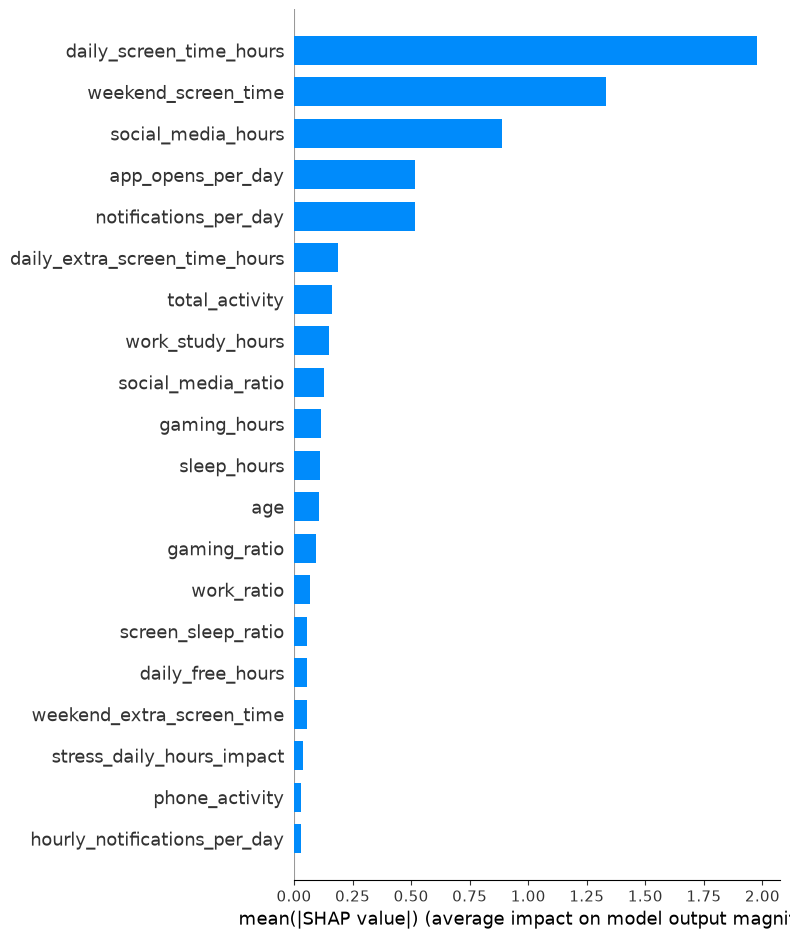

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

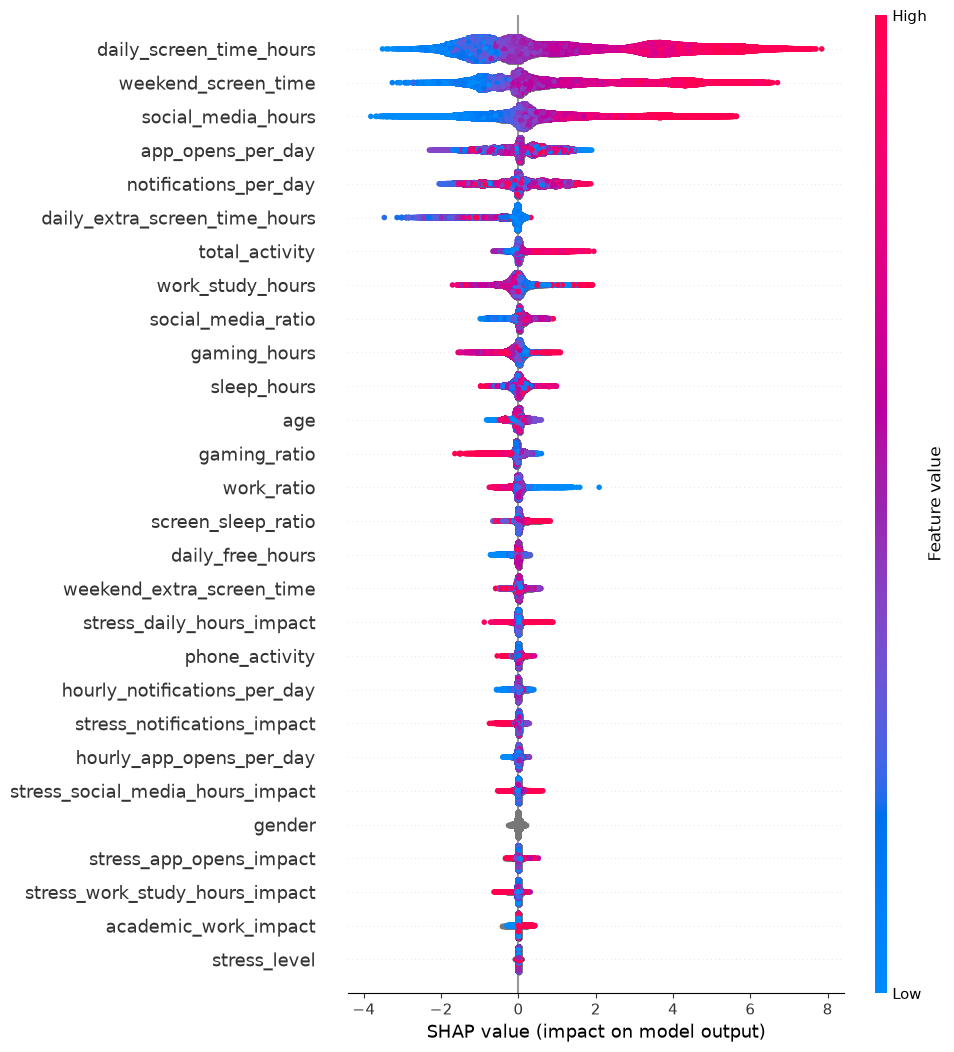

In [27]:
shap.plots.beeswarm(shap_values, max_display=30)